In [648]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [649]:
def round_unc(value, uncertainty, cutoff=2, extract_magnitude=False):
    scalar_input = np.isscalar(value)

    value = np.atleast_1d(value).astype(float)
    uncertainty = np.atleast_1d(uncertainty).astype(float)

    exp = np.floor(np.log10(np.abs(uncertainty)))
    first_digit = (uncertainty / 10**exp).astype(int)
    sigs = np.where(first_digit <= cutoff, 2, 1)

    rounding_decimals = (-exp + (sigs - 1)).astype(int)
    rounded_uncertainty = (
        np.round(uncertainty * 10.0**rounding_decimals) / 10.0**rounding_decimals
    )

    decimals = (-np.floor(np.log10(rounded_uncertainty)) + (sigs - 1)).astype(int)
    rounded_value = np.round(value * 10.0**decimals) / 10.0**decimals

    if extract_magnitude:
        exponent = np.floor(np.log10(np.abs(rounded_value))).astype(int)
        mantissa_value = rounded_value / 10.0**exponent
        mantissa_uncertainty = rounded_uncertainty / 10.0**exponent

        if scalar_input:
            return mantissa_value[0], mantissa_uncertainty[0], exponent[0]
        return mantissa_value, mantissa_uncertainty, exponent

    if scalar_input:
        return rounded_value[0], rounded_uncertainty[0]
    return rounded_value, rounded_uncertainty

In [650]:
y_offset = 0.00  # cm
y_offset_unc = 0.05  # cm

In [651]:
coords_df = pd.read_csv("coords.csv")
coords_df

,anode_voltage,x1,x2,x3,x4,x5,y1,y2,y3,y4,...,yn2,yn3,yn4,yn5,coord_unc,current,voltage,voltagen,current_unc,currentn
0,1000,2.0,4.0,6.0,8.0,10.0,-0.75,-2,-4.0,-6.75,...,2,3.75,6.75,9.50,0.05,0.0850,1.09,1.102,0.05,-0.0850
1,1500,2.0,4.0,6.0,8.0,10.0,-0.75,-2,-4.0,-6.75,...,2,4.00,6.50,9.75,0.05,0.1052,1.35,1.364,0.05,-0.1052
2,2000,2.0,4.0,6.0,8.0,10.0,-0.75,-2,-4.0,-6.75,...,2,4.00,6.75,10.00,0.05,0.1238,1.59,1.662,0.05,-0.1238
3,2500,2.0,4.0,6.0,8.0,10.0,-0.75,-2,-4.0,-6.75,...,2,4.25,7.00,10.00,0.05,0.1393,1.79,1.804,0.05,-0.1393
4,3000,2.0,4.0,6.0,8.0,10.0,-0.75,-2,-4.0,-6.75,...,2,4.25,7.00,10.25,0.05,0.1540,1.98,1.990,0.05,-0.1540


In [652]:
ys = [f"y{i}" for i in range(1, 6)]
yns = [f"yn{i}" for i in range(1, 6)]
xs = [f"x{i}" for i in range(1, 6)]

In [653]:
coords_df[ys + yns] = coords_df[ys + yns] * 0.2 * 0.01  # cells -> cm -> m
coords_df[ys + yns] = coords_df[ys + yns] - y_offset
coords_df[xs] = coords_df[xs] * 0.01  # cm -> m

In [654]:
first_ys = [f"y{i}" for i in range(1, 6)]
second_ys = [f"yn{i}" for i in range(1, 6)]
for y, yn in zip(first_ys, second_ys):
    coords_df[f"{y}avg"] = (coords_df[y].abs() + coords_df[yn].abs()) / 2

In [655]:
coords_df

,anode_voltage,x1,x2,x3,x4,x5,y1,y2,y3,y4,...,current,voltage,voltagen,current_unc,currentn,y1avg,y2avg,y3avg,y4avg,y5avg
0,1000,0.02,0.04,0.06,0.08,0.1,-0.0015,-0.004,-0.008,-0.0135,...,0.0850,1.09,1.102,0.05,-0.0850,0.0015,0.004,0.00775,0.01350,0.01950
1,1500,0.02,0.04,0.06,0.08,0.1,-0.0015,-0.004,-0.008,-0.0135,...,0.1052,1.35,1.364,0.05,-0.1052,0.0015,0.004,0.00800,0.01325,0.01975
2,2000,0.02,0.04,0.06,0.08,0.1,-0.0015,-0.004,-0.008,-0.0135,...,0.1238,1.59,1.662,0.05,-0.1238,0.0015,0.004,0.00800,0.01350,0.02000
3,2500,0.02,0.04,0.06,0.08,0.1,-0.0015,-0.004,-0.008,-0.0135,...,0.1393,1.79,1.804,0.05,-0.1393,0.0015,0.004,0.00825,0.01375,0.02000
4,3000,0.02,0.04,0.06,0.08,0.1,-0.0015,-0.004,-0.008,-0.0135,...,0.1540,1.98,1.990,0.05,-0.1540,0.0015,0.004,0.00825,0.01375,0.02025


In [656]:
for i in range(1, 6):
    coords_df[f"y{i} - yavg"] = np.abs(coords_df[f"y{i}"]) - coords_df[f"y{i}avg"]
    coords_df[f"yn{i} - yavg"] = np.abs(coords_df[f"yn{i}"]) - coords_df[f"y{i}avg"]


diffs = [f"y{i} - yavg" for i in range(1, 6)] + [f"yn{i} - yavg" for i in range(1, 6)]
coords_df[diffs]


,y1 - yavg,y2 - yavg,y3 - yavg,y4 - yavg,y5 - yavg,yn1 - yavg,yn2 - yavg,yn3 - yavg,yn4 - yavg,yn5 - yavg
0,0.0,0.0,0.00025,0.00000,0.00050,0.0,0.0,-0.00025,0.00000,-0.00050
1,0.0,0.0,0.00000,0.00025,0.00025,0.0,0.0,0.00000,-0.00025,-0.00025
2,0.0,0.0,0.00000,0.00000,0.00000,0.0,0.0,0.00000,0.00000,0.00000
3,0.0,0.0,-0.00025,-0.00025,0.00000,0.0,0.0,0.00025,0.00025,0.00000
4,0.0,0.0,-0.00025,-0.00025,-0.00025,0.0,0.0,0.00025,0.00025,0.00025


In [657]:
def partial_x_r(x, r):
    return x / r


def r_unc(x, y, r, x_unc, y_unc):
    px = partial_x_r(x, r)
    py = partial_x_r(y, r)
    return np.sqrt(px**2 * x_unc**2 + py**2 * y_unc**2)

In [658]:
def circ_eq(beta, coords):
    """
    Implicit function that should return 0 for points on the
    circle.
    """

    r, x0, y0 = beta
    x, y = coords
    return np.sqrt((x - x0) ** 2 + (y - y0) ** 2) - r

In [659]:
# Fit the circle to the points using uncertainties
from scipy.odr import ODR, Data, Model
from lmfit import Parameters, minimize


def fit_circle(row):
    x_list = [f"x{i}" for i in range(1, 6)]
    y_list = [f"y{i}avg" for i in range(1, 6)]
    xs = np.array(row[x_list].values)
    ys = np.array(row[y_list].values)
    arr = np.array([xs, ys])

    model = Model(circ_eq, implicit=True)
    odr = ODR(Data(arr, y=1), model, beta0=[1, 0, 0])
    res = odr.run()

    r, x0, y0 = res.beta
    r_unc, x0_unc, y0_unc = res.sd_beta

    return np.array([r, r_unc, x0, x0_unc, y0, y0_unc])


# def fit_circle(row):
#     x_list = [f"x{i}" for i in range(1, 6)]
#     y_list = [f"y{i}avg" for i in range(1, 6)]
#     xs = np.array(row[x_list].values)
#     ys = np.array(row[y_list].values)
#
#     # Calculate better initial guesses
#     x_mean, y_mean = np.mean(xs), np.mean(ys)
#     distances = np.sqrt((xs - x_mean) ** 2 + (ys - y_mean) ** 2)
#     r_initial = np.mean(distances)
#
#     # Set reasonable bounds for radius (adjust these based on your data)
#     min_radius = 0.1  # minimum radius in meters (adjust as needed)
#     max_radius = 0.5  # maximum radius in meters (adjust as needed)
#
#     # Create model and data
#     arr = np.array([xs, ys])
#     model = Model(circ_eq, implicit=True)
#     data = Data(arr, y=1)
#
#     # Create ODR with better initial guesses
#     odr = ODR(data, model, beta0=[r_initial, x_mean, y_mean])
#
#     # Set constraints (radius bounded, center unconstrained)
#     odr.set_job(fit_type=0)  # Explicit ODR fit
#     odr.set_constr(
#         cons=1, lower=[min_radius, -np.inf, -np.inf], upper=[max_radius, np.inf, np.inf]
#     )
#
#     # Run the fit
#     res = odr.run()
#
#     # Extract results
#     r, x0, y0 = res.beta
#     r_unc, x0_unc, y0_unc = res.sd_beta
#
#     return np.array([r, r_unc, x0, x0_unc, y0, y0_unc])


def circ_eq_lmfit(params, x, data=None):
    r = params["r"]
    x0 = params["x0"]
    y0 = params["y0"]
    model = (x[0] - x0) ** 2 + (x[1] - y0) ** 2 - r**2
    if data is None:
        return model
    return model - data


def fit_circle_lmfit(row):
    x_list = [f"x{i}" for i in range(1, 6)]
    y_list = [f"y{i}avg" for i in range(1, 6)]
    xs = np.array(row[x_list].values)
    ys = np.array(row[y_list].values)
    arr = np.array([xs, ys])

    params = Parameters()
    params.add("r", value=1, min=0.001, max=100)
    params.add("x0", value=0)
    params.add("y0", value=0)

    result = minimize(circ_eq_lmfit, params, args=(arr, np.zeros(arr.shape[1])))

    r = result.params["r"].value
    r_err = result.params["r"].stderr
    x0 = result.params["x0"].value
    x0_err = result.params["x0"].stderr
    y0 = result.params["y0"].value
    y0_err = result.params["y0"].stderr

    return np.array([r, r_err, x0, x0_err, y0, y0_err])


COORD_UNC = 0.05  # cm


def fit_circle_simple(row):
    x_list = [f"x{i}" for i in range(1, 6)]
    y_list = [f"y{i}avg" for i in range(1, 6)]
    xs = np.array(row[x_list].values)
    ys = np.array(row[y_list].values)

    A = np.column_stack([xs, ys, np.ones_like(xs)])
    b = xs**2 + ys**2

    c = np.linalg.lstsq(A, b, rcond=None)[0]

    x_center = c[0] / 2
    y_center = c[1] / 2
    radius = np.sqrt(c[2] + x_center**2 + y_center**2)

    radius_unc = r_unc(x_center, y_center, radius, COORD_UNC, COORD_UNC)

    return np.array([radius, x_center, y_center, radius_unc])


# coords_df[["r", "x0", "y0", "r_unc"]] = coords_df.apply(
#     fit_circle_simple, axis=1, result_type="expand"
# )

coords_df[["r", "r_unc", "x0", "x0_unc", "y0", "y0_unc"]] = coords_df.apply(
    fit_circle_lmfit, axis=1, result_type="expand"
)

coords_df

,anode_voltage,x1,x2,x3,x4,x5,y1,y2,y3,y4,...,y4 - yavg,yn4 - yavg,y5 - yavg,yn5 - yavg,r,r_unc,x0,x0_unc,y0,y0_unc
0,1000,0.02,0.04,0.06,0.08,0.1,-0.0015,-0.004,-0.008,-0.0135,...,0.00000,0.00000,0.00050,-0.00050,0.325124,0.043462,-0.011643,0.009820,0.325051,0.042556
1,1500,0.02,0.04,0.06,0.08,0.1,-0.0015,-0.004,-0.008,-0.0135,...,0.00025,-0.00025,0.00025,-0.00025,0.327478,0.011065,-0.012537,0.002514,0.327321,0.010831
2,2000,0.02,0.04,0.06,0.08,0.1,-0.0015,-0.004,-0.008,-0.0135,...,0.00000,0.00000,0.00000,0.00000,0.318365,0.018058,-0.011588,0.004168,0.318248,0.017665
3,2500,0.02,0.04,0.06,0.08,0.1,-0.0015,-0.004,-0.008,-0.0135,...,-0.00025,0.00025,0.00000,0.00000,0.340391,0.035765,-0.017004,0.008275,0.339790,0.034959
4,3000,0.02,0.04,0.06,0.08,0.1,-0.0015,-0.004,-0.008,-0.0135,...,-0.00025,0.00025,-0.00025,0.00025,0.325810,0.025602,-0.014407,0.005992,0.325414,0.025019


In [660]:
coords_df["r"]

0    0.325124
1    0.327478
2    0.318365
3    0.340391
4    0.325810
Name: r, dtype: float64

In [661]:
coords_df["r_unc"]

0    0.043462
1    0.011065
2    0.018058
3    0.035765
4    0.025602
Name: r_unc, dtype: float64

In [662]:
fit_circle(coords_df.iloc[0])

array([ 0.33678345,  0.01538926, -0.01424444,  0.0010684 ,  0.33646292,
        0.0163648 ])

In [663]:
coords_df

,anode_voltage,x1,x2,x3,x4,x5,y1,y2,y3,y4,...,y4 - yavg,yn4 - yavg,y5 - yavg,yn5 - yavg,r,r_unc,x0,x0_unc,y0,y0_unc
0,1000,0.02,0.04,0.06,0.08,0.1,-0.0015,-0.004,-0.008,-0.0135,...,0.00000,0.00000,0.00050,-0.00050,0.325124,0.043462,-0.011643,0.009820,0.325051,0.042556
1,1500,0.02,0.04,0.06,0.08,0.1,-0.0015,-0.004,-0.008,-0.0135,...,0.00025,-0.00025,0.00025,-0.00025,0.327478,0.011065,-0.012537,0.002514,0.327321,0.010831
2,2000,0.02,0.04,0.06,0.08,0.1,-0.0015,-0.004,-0.008,-0.0135,...,0.00000,0.00000,0.00000,0.00000,0.318365,0.018058,-0.011588,0.004168,0.318248,0.017665
3,2500,0.02,0.04,0.06,0.08,0.1,-0.0015,-0.004,-0.008,-0.0135,...,-0.00025,0.00025,0.00000,0.00000,0.340391,0.035765,-0.017004,0.008275,0.339790,0.034959
4,3000,0.02,0.04,0.06,0.08,0.1,-0.0015,-0.004,-0.008,-0.0135,...,-0.00025,0.00025,-0.00025,0.00025,0.325810,0.025602,-0.014407,0.005992,0.325414,0.025019


In [664]:
coords_df[["anode_voltage", "r", "r_unc", "current", "current_unc"]].to_markdown()

'|    |   anode_voltage |        r |     r_unc |   current |   current_unc |\n|---:|----------------:|---------:|----------:|----------:|--------------:|\n|  0 |            1000 | 0.325124 | 0.0434625 |    0.085  |          0.05 |\n|  1 |            1500 | 0.327478 | 0.0110653 |    0.1052 |          0.05 |\n|  2 |            2000 | 0.318365 | 0.0180578 |    0.1238 |          0.05 |\n|  3 |            2500 | 0.340391 | 0.0357648 |    0.1393 |          0.05 |\n|  4 |            3000 | 0.32581  | 0.0256016 |    0.154  |          0.05 |'

In [665]:
reported_r, reported_r_unc = round_unc(
    coords_df["r"], coords_df["r_unc"], extract_magnitude=False
)
CURRENT_UNC = 0.0001  # A
reported_I, reported_I_unc = round_unc(
    coords_df["current"], CURRENT_UNC, extract_magnitude=False
)


In [666]:
coords_df["r_unc"]

0    0.043462
1    0.011065
2    0.018058
3    0.035765
4    0.025602
Name: r_unc, dtype: float64

In [667]:
reported_r_unc

array([0.04 , 0.011, 0.018, 0.04 , 0.026])

In [668]:
report_df = pd.DataFrame(
    {
        "anode_voltage": coords_df["anode_voltage"],
        "r": reported_r,
        "r_unc": reported_r_unc,
        "I": reported_I,
    }
)
report_df.to_markdown()

'|    |   anode_voltage |     r |   r_unc |      I |\n|---:|----------------:|------:|--------:|-------:|\n|  0 |            1000 | 0.33  |   0.04  | 0.085  |\n|  1 |            1500 | 0.327 |   0.011 | 0.1052 |\n|  2 |            2000 | 0.318 |   0.018 | 0.1238 |\n|  3 |            2500 | 0.34  |   0.04  | 0.1393 |\n|  4 |            3000 | 0.326 |   0.026 | 0.154  |'

In [669]:
import scipy.constants as const

N_TURNS = 320
D = 0.15  # m
report_df["b_field"] = (
    16 * const.mu_0 * N_TURNS * coords_df["current"] / (np.sqrt(125) * D)
)


In [670]:
def B_field_unc(current, current_unc, N, N_unc, D, D_unc):
    def partial_D_B(N, I, D):
        return -16 * const.mu_0 * N * I / (np.sqrt(125) * D)

    def partial_N_B(N, I, D):
        return 16 * const.mu_0 * I / (np.sqrt(125) * D)

    def partial_I_B(N, I, D):
        return 16 * const.mu_0 * N / (np.sqrt(125) * D)

    t1 = partial_D_B(N, current, D) * D_unc
    t2 = partial_N_B(N, current, D) * N_unc
    t3 = partial_I_B(N, current, D) * current_unc * np.ones_like(current)

    print("Shape of t1", t1.shape)
    print("Shape of t2", t2.shape)
    print("Shape of t3", t3.shape)

    terms = np.concatenate(
        [
            t1,
            t2,
            t3,
        ],
        axis=0,
    )

    return np.sqrt(np.sum(terms**2))


B_field_unc(
    current=coords_df["current"],
    current_unc=0.0001,
    N=N_TURNS,
    N_unc=0,
    D=D,
    D_unc=0.005,  # Half of a cm
)


Shape of t1 (5,)
Shape of t2 (5,)
Shape of t3 (5,)


np.float64(5.382678346806252e-06)

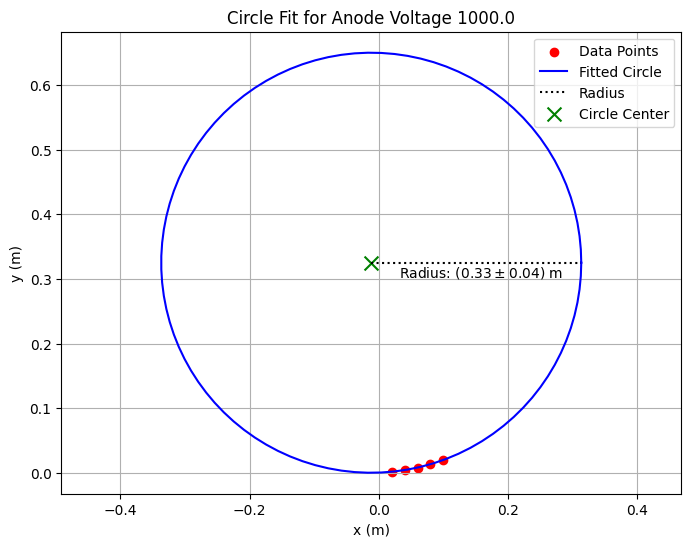

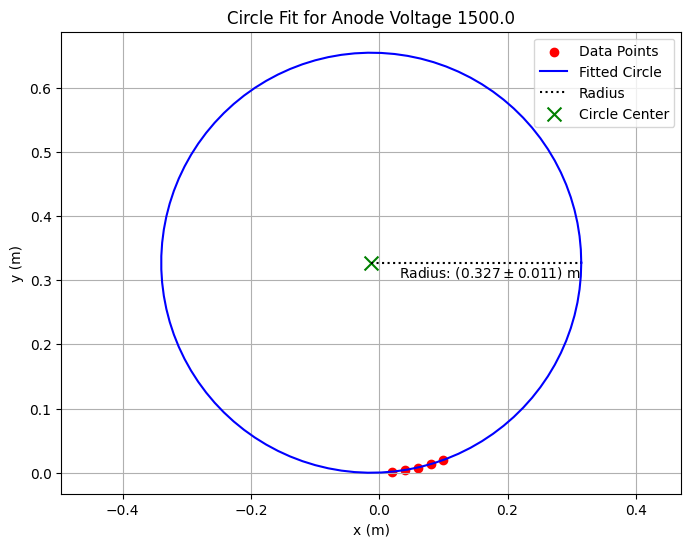

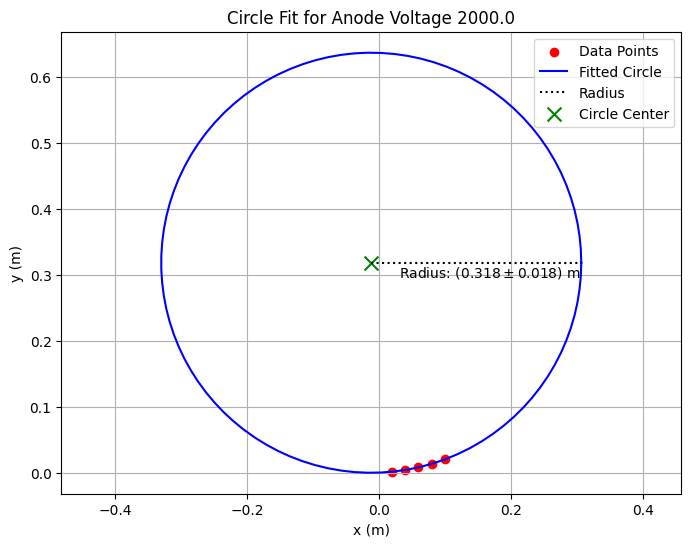

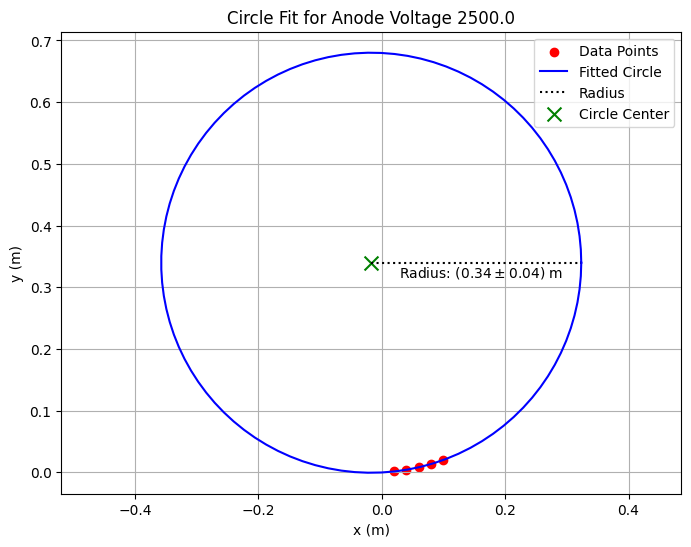

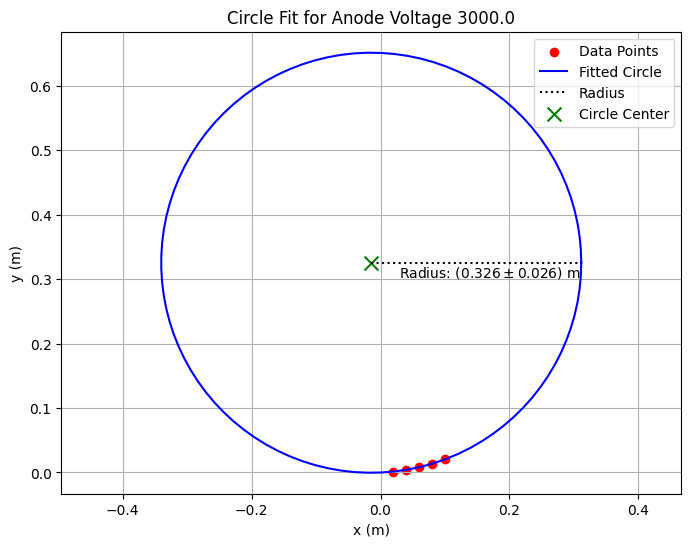

In [671]:
# Plot the circle fit for a specific row
def plot_circle_fit(row_index, save_target=None):
    row = coords_df.iloc[row_index]

    # Extract x and y coordinates
    x_list = [f"x{i}" for i in range(1, 6)]
    y_list = [f"y{i}avg" for i in range(1, 6)]
    xs = row[x_list].values
    ys = row[y_list].values

    # Extract circle parameters
    r, r_unc, x0, y0 = row["r"], row["r_unc"], row["x0"], row["y0"]

    # Round radius with uncertainty
    r_rounded, r_rounded_unc = round_unc(r, r_unc)

    # Create plot
    plt.figure(figsize=(8, 6))
    plt.scatter(xs, ys, color="red", label="Data Points")

    # Plot fitted circle
    theta = np.linspace(0, 2 * np.pi, 100)
    circle_x = x0 + r * np.cos(theta)
    circle_y = y0 + r * np.sin(theta)
    plt.plot(circle_x, circle_y, color="blue", label="Fitted Circle")

    # Draw radius line
    plt.plot([x0, x0 + r], [y0, y0], color="black", linestyle=":", label="Radius")

    # Mark and annotate the center point
    plt.scatter(x0, y0, color="green", marker="x", s=100, label="Circle Center")
    # plt.annotate(
    #     f"Center: ({x0:.4f}, {y0:.4f})",
    #     (x0, y0),
    #     xytext=(10, 10),
    #     textcoords="offset points",
    # )

    # Annotate radius with uncertainty
    plt.annotate(
        rf"Radius: $({r_rounded} \pm {r_rounded_unc})$ m",
        (
            x0 + r / 15,
            y0,
        ),  # Moved annotation to the left by changing the multiplier from 1/2 to 1/3
        xytext=(10, -10),
        textcoords="offset points",
        color="black",
    )

    plt.title(f"Circle Fit for Anode Voltage {row['anode_voltage']}")
    plt.xlabel("x (m)")
    plt.ylabel("y (m)")
    plt.axis("equal")
    plt.legend()
    plt.grid(True)

    # Save plot if target is specified
    if save_target is not None:
        plt.savefig(save_target, format="png")

    plt.show()


# Example: Plot circle fit for the first row
for i in range(5):
    plot_circle_fit(i, save_target=f"circle_fit_{i}.png")


$$
B = \frac{
    16 \mu_0 N I
}{
\sqrt{125} D
}  \quad
\frac{e}{m} =
\frac{
2V_a
}{
B^2 r^2
}
$$


In [672]:
coords_df["anode_voltage"]

0    1000
1    1500
2    2000
3    2500
4    3000
Name: anode_voltage, dtype: int64

In [673]:
import scipy.constants as const

n = 320  # turns
D = 0.15  # m
mu_0 = 4 * np.pi * 10**-7
coords_df["B"] = 16 * mu_0 * n * coords_df["current"] / (np.sqrt(125) * D)
coords_df["e_to_m"] = (
    2 * coords_df["anode_voltage"] / (coords_df["B"] ** 2 * coords_df["r"] ** 2)
)

In [674]:
coords_df["e_to_m"]

0    1.779211e+11
1    1.717344e+11
2    1.749443e+11
3    1.510934e+11
4    1.619251e+11
Name: e_to_m, dtype: float64

In [675]:
len(coords_df["e_to_m"])

5

In [676]:
# coords_df = coords_df.drop(3)

In [677]:
std_err = coords_df["e_to_m"].std(ddof=1) / len(coords_df["e_to_m"]) ** 0.5
mean_val = coords_df["e_to_m"].mean()

print(f"{std_err:.3e}")
print(f"{mean_val:.3e}")

4.910e+09
1.675e+11


In [678]:
mean_val + std_err

np.float64(172433864777.69315)

In [679]:
import scipy.constants as const

accepted_e_to_m = const.e / const.m_e
print(accepted_e_to_m)

175882000837.79984


In [680]:
import scipy.constants as const

# Retrieve electron charge information
charge_value, charge_unit, charge_uncertainty = const.physical_constants[
    "elementary charge"
]

# Retrieve electron mass information
mass_value, mass_unit, mass_uncertainty = const.physical_constants["electron mass"]

# Display results
print(f"Electron charge: {charge_value:.10e} ± {charge_uncertainty:.1e} {charge_unit}")
print(f"Electron mass:   {mass_value:.10e} ± {mass_uncertainty:.1e} {mass_unit}")


Electron charge: 1.6021766340e-19 ± 0.0e+00 C
Electron mass:   9.1093837139e-31 ± 2.8e-40 kg


In [681]:
import math


def charge_to_mass_ratio_uncertainty(q, sigma_q, m, sigma_m):
    """
    Calculate the charge-to-mass ratio and its propagated uncertainty.

    Parameters:
    -----------
    q : float
        Charge value
    sigma_q : float
        Uncertainty in charge
    m : float
        Mass value
    sigma_m : float
        Uncertainty in mass

    Returns:
    --------
    (float, float)
        Tuple of (ratio, uncertainty_in_ratio)
    """
    ratio = q / m
    uncertainty = math.sqrt((sigma_q / m) ** 2 + (q * sigma_m / m**2) ** 2)
    return ratio, uncertainty


$$\left(\frac{\delta(e/m)}{e/m}\right) = \sqrt{\left(\frac{\delta V_a}{V_a}\right)^2 + 4\left(\frac{\delta I}{I}\right)^2 + 4\left(\frac{\delta r}{r}\right)^2 + 4\left(\frac{\delta D}{D}\right)^2}$$


In [682]:
import numpy as np


def calculate_em_uncertainty(e_m, Va, delta_Va, I, delta_I, r, delta_r, D, delta_D):
    """
    Calculate the absolute uncertainty in the charge-to-mass ratio (e/m).

    Parameters:
    -----------
    e_m : float
        The calculated charge-to-mass ratio.
    Va : float
        The accelerating voltage.
    delta_Va : float
        The uncertainty in the accelerating voltage.
    I : float
        The current.
    delta_I : float
        The uncertainty in the current.
    r : float
        The radius.
    delta_r : float
        The uncertainty in the radius.
    D : float
        The diameter (or distance).
    delta_D : float
        The uncertainty in the diameter (or distance).

    Returns:
    --------
    float
        The absolute uncertainty in e/m.
    """
    # Calculate relative uncertainties
    rel_Va = delta_Va / Va
    rel_I = delta_I / I
    rel_r = delta_r / r
    rel_D = delta_D / D

    print("rel_Va", rel_Va)
    print("rel_I", rel_I)
    print("rel_r", rel_r)
    print("rel_D", rel_D)

    # Calculate relative uncertainty in e/m using the given formula
    rel_em = np.sqrt(
        (rel_Va) ** 2 + 4 * (rel_I) ** 2 + 4 * (rel_r) ** 2 + 4 * (rel_D) ** 2
    )

    # Calculate absolute uncertainty in e/m
    delta_em = e_m * rel_em
    print("Value of rel_em", rel_em)

    return delta_em

In [683]:
coords_df["r"]

0    0.325124
1    0.327478
2    0.318365
3    0.340391
4    0.325810
Name: r, dtype: float64

In [684]:
coords_df["r_unc"]

0    0.043462
1    0.011065
2    0.018058
3    0.035765
4    0.025602
Name: r_unc, dtype: float64

In [685]:
coords_df["anode_voltage"]

0    1000
1    1500
2    2000
3    2500
4    3000
Name: anode_voltage, dtype: int64

In [686]:
1 / coords_df["anode_voltage"]

0    0.001000
1    0.000667
2    0.000500
3    0.000400
4    0.000333
Name: anode_voltage, dtype: float64

In [687]:
0.0001 / coords_df["current"]

0    0.001176
1    0.000951
2    0.000808
3    0.000718
4    0.000649
Name: current, dtype: float64

In [688]:
Va_unc = 1  # V
current_unc = 0.0001  # A
# TODO: this r_unc is WRONG.
# r_unc = 0.05 * 0.01  # cm -> m
D_unc = 0.005  # m (5 mm)

coords_df["e_to_m_unc"] = calculate_em_uncertainty(
    e_m=coords_df["e_to_m"],
    Va=coords_df["anode_voltage"],
    delta_Va=Va_unc,
    I=coords_df["current"],
    delta_I=current_unc,
    r=coords_df["r"],
    delta_r=coords_df["r_unc"],
    D=D,
    delta_D=D_unc,
)

coords_df["e_to_m_unc"]


rel_Va 0    0.001000
1    0.000667
2    0.000500
3    0.000400
4    0.000333
Name: anode_voltage, dtype: float64
rel_I 0    0.001176
1    0.000951
2    0.000808
3    0.000718
4    0.000649
Name: current, dtype: float64
rel_r 0    0.133680
1    0.033789
2    0.056720
3    0.105070
4    0.078578
dtype: float64
rel_D 0.03333333333333333
Value of rel_em 0    0.275558
1    0.094949
2    0.131591
3    0.220466
4    0.170718
dtype: float64


0    4.902754e+10
1    1.630606e+10
2    2.302107e+10
3    3.331098e+10
4    2.764349e+10
Name: e_to_m_unc, dtype: float64

In [689]:
print(f"{coords_df['e_to_m_unc'].std(ddof=1):.2e}")

1.24e+10


In [690]:
e_over_m_acc, e_over_m_acc_unc = charge_to_mass_ratio_uncertainty(
    q=charge_value, sigma_q=charge_uncertainty, m=mass_value, sigma_m=mass_uncertainty
)
print(e_over_m_acc, e_over_m_acc_unc)

175882000837.79984 54.061791424416626


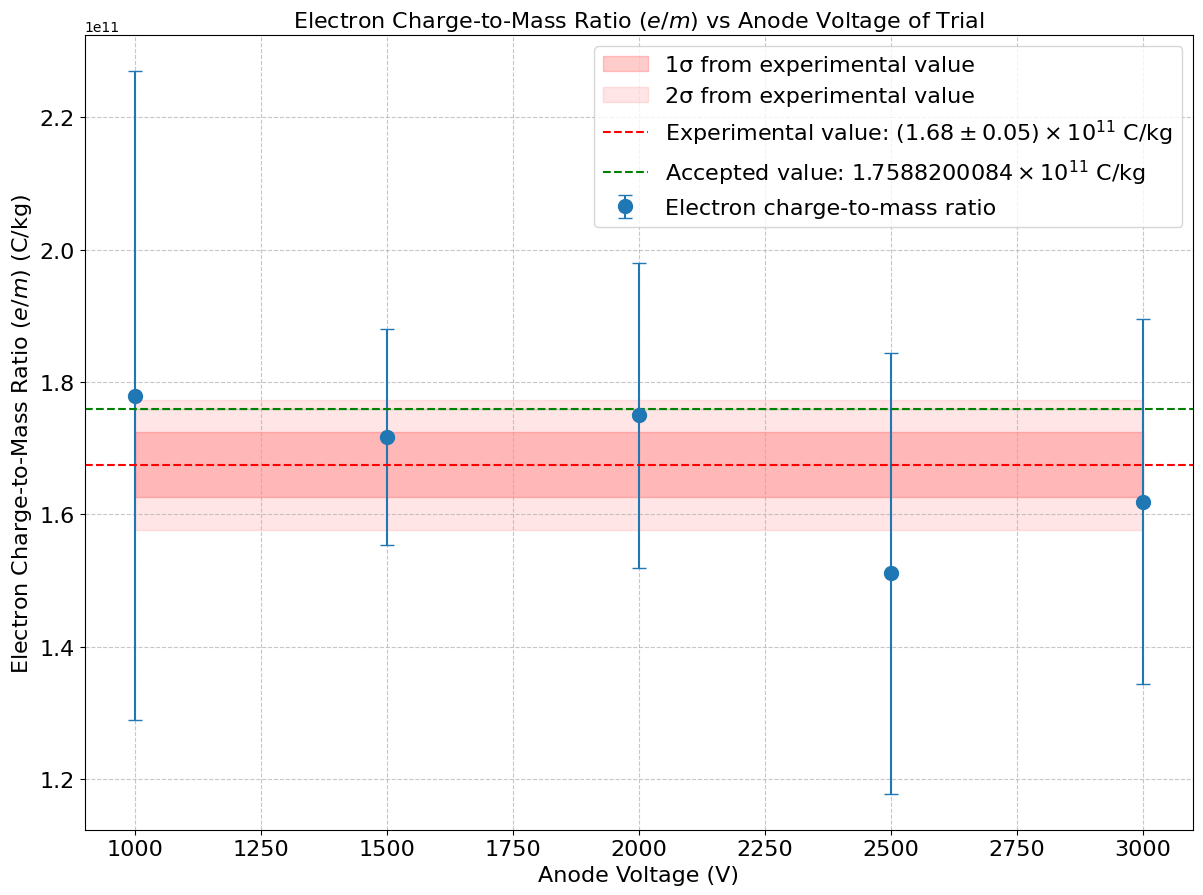

In [691]:
import matplotlib.pyplot as plt
import numpy as np
from uncertainties import ufloat
from uncertainties.unumpy import nominal_values, std_devs

# Create ufloat for mean and standard error

sdom = coords_df["e_to_m"].std(ddof=1) / np.sqrt(5)

mean_val_ufloat = ufloat(mean_val, sdom)
accepted_ufloat = ufloat(e_over_m_acc, e_over_m_acc_unc)

display_mean, display_std, display_exp = round_unc(
    mean_val, std_err, extract_magnitude=True
)
display_acc_mean, display_acc_std, display_acc_exp = round_unc(
    e_over_m_acc, e_over_m_acc_unc, extract_magnitude=True
)

plt.figure(figsize=(12, 9))
plt.errorbar(
    coords_df["anode_voltage"],
    coords_df["e_to_m"],
    yerr=coords_df["e_to_m_unc"],
    fmt="o",
    capsize=5,
    label="Electron charge-to-mass ratio",
    markersize=10,
)

# Add shaded region for standard deviation of the mean
plt.fill_between(
    coords_df["anode_voltage"],
    mean_val - sdom,
    mean_val + sdom,
    alpha=0.2,
    color="red",
    label=f"1σ from experimental value",
)

# Add shaded region for 2σ of the mean
plt.fill_between(
    coords_df["anode_voltage"],
    mean_val - 2 * sdom,
    mean_val + 2 * sdom,
    alpha=0.1,
    color="red",
    label=f"2σ from experimental value",
)

# Add shaded region for accepted value uncertainty
plt.fill_between(
    coords_df["anode_voltage"],
    e_over_m_acc - e_over_m_acc_unc,
    e_over_m_acc + e_over_m_acc_unc,
    alpha=0.2,
    color="green",
)

plt.title(
    "Electron Charge-to-Mass Ratio ($e/m$) vs Anode Voltage of Trial", fontsize=16
)
plt.xlabel("Anode Voltage (V)", fontsize=16)
plt.ylabel("Electron Charge-to-Mass Ratio ($e/m$) (C/kg)", fontsize=16)
plt.grid(True, linestyle="--", alpha=0.7)

# Add horizontal line for mean value with uncertainty
plt.axhline(
    y=mean_val,
    color="r",
    linestyle="--",
    label=f"Experimental value: $({display_mean} \\pm {display_std}) \\times 10^{{{display_exp}}}$ C/kg",
)

# Add horizontal line for accepted value with uncertainty
plt.axhline(
    y=e_over_m_acc,
    color="g",
    linestyle="--",
    label=f"Accepted value: ${display_acc_mean}  \\times 10^{{{display_acc_exp}}}$ C/kg",
)

plt.legend(fontsize=16)
plt.tight_layout()
plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

# Increase tick label size
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.savefig("e_to_m_vs_anode_voltage.png")
plt.show()


In [692]:
coords_df["e_to_m"]

0    1.779211e+11
1    1.717344e+11
2    1.749443e+11
3    1.510934e+11
4    1.619251e+11
Name: e_to_m, dtype: float64

In [693]:
coords_df["e_to_m_unc"]

0    4.902754e+10
1    1.630606e+10
2    2.302107e+10
3    3.331098e+10
4    2.764349e+10
Name: e_to_m_unc, dtype: float64

In [694]:
em_report = pd.DataFrame()
em_report["em"], em_report["em_unc"] = round_unc(
    coords_df["e_to_m"], coords_df["e_to_m_unc"]
)
em_report["anode_voltage"] = coords_df["anode_voltage"]
em_report.to_markdown()

'|    |       em |   em_unc |   anode_voltage |\n|---:|---------:|---------:|----------------:|\n|  0 | 1.8e+11  |  5e+10   |            1000 |\n|  1 | 1.72e+11 |  1.6e+10 |            1500 |\n|  2 | 1.75e+11 |  2.3e+10 |            2000 |\n|  3 | 1.5e+11  |  3e+10   |            2500 |\n|  4 | 1.62e+11 |  2.8e+10 |            3000 |'

$$
\frac{m}{e} = \frac{B^2 r^2}{2V_a}
$$


$$
r = \sqrt { \frac{2mV_a}{eB^2} }
$$


In [695]:
omega_p = (1 * 100e-6) / ((2 / 5) * 0.4 * 0.02**2)
omega_p

1.5624999999999998

In [696]:
coords_df["r"]

0    0.325124
1    0.327478
2    0.318365
3    0.340391
4    0.325810
Name: r, dtype: float64

In [697]:
from scipy import stats


def B_unc(I, I_unc, D, D_unc, B):
    return B * np.sqrt((I_unc / I) ** 2 + (D_unc / D) ** 2)


def B2r2_unc(B, B_unc, r, r_unc):
    return np.sqrt((2 * B * r * B_unc) ** 2 + (B**2 * 2 * r * r_unc) ** 2)


In [698]:
coords_df["2Va"] = 2 * coords_df["anode_voltage"]
coords_df["2Va_unc"] = 2 * 1

coords_df["B2r2"] = coords_df["B"] ** 2 * coords_df["r"] ** 2
coords_df["B_unc"] = B_unc(
    I=coords_df["current"],
    I_unc=0.0001,
    D=0.15,
    D_unc=0.001,
    B=coords_df["B"],
)
coords_df["B2r2_unc"] = B2r2_unc(
    B=coords_df["B"],
    B_unc=coords_df["B_unc"],
    r=coords_df["r"],
    r_unc=coords_df["r_unc"],
)

Slope: (1.56 ± 0.1) * 10^{11} V/((T^2 · m^2)
Intercept: (2.8 ± 2.0) * 10^{2} V


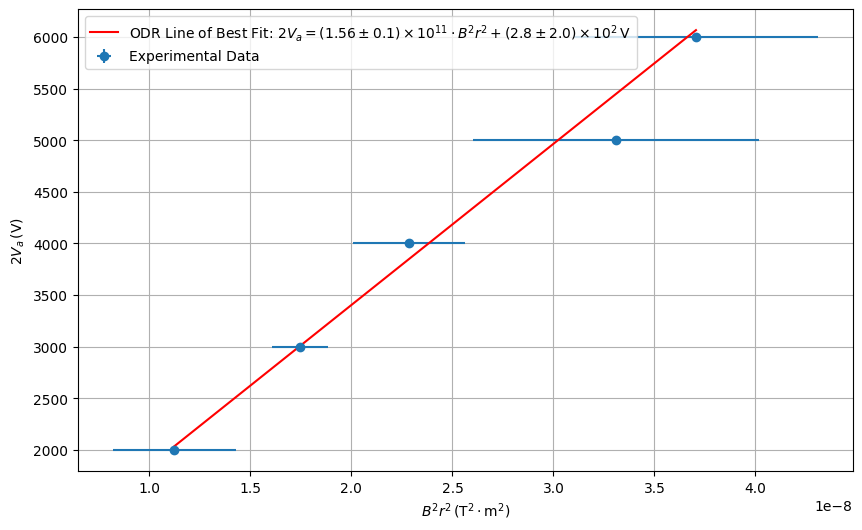

In [701]:
from scipy import odr

plt.figure(figsize=(10, 6))
plt.errorbar(
    coords_df["B2r2"],
    coords_df["2Va"],
    xerr=coords_df["B2r2_unc"],
    yerr=coords_df["2Va_unc"],
    fmt="o",
    label="Experimental Data",
)


# Perform Orthogonal Distance Regression (ODR)
def linear_func(p, x):
    return p[0] * x + p[1]


# Create ODR model
model = odr.Model(linear_func)
data = odr.RealData(
    coords_df["B2r2"],
    coords_df["2Va"],
    sx=coords_df["B2r2_unc"],
    sy=coords_df["2Va_unc"],
)
odr_fit = odr.ODR(data, model, beta0=[1, 0])
out = odr_fit.run()

# Extract results
slope = out.beta[0]
intercept = out.beta[1]
slope_std_err = out.sd_beta[0]
intercept_std_err = out.sd_beta[1]

# Round slope and intercept with uncertainties
slope_rounded, slope_std_err_rounded, slope_magnitude = round_unc(
    slope, slope_std_err, extract_magnitude=True
)
intercept_rounded, intercept_std_err_rounded, intercept_magnitude = round_unc(
    intercept, intercept_std_err, extract_magnitude=True
)
# Plot line of best fit
line_x = np.linspace(coords_df["B2r2"].min(), coords_df["B2r2"].max(), 100)
line_y = slope * line_x + intercept
plt.plot(line_x, line_y, color="red", label=r"ODR Line of Best Fit: $2V_a = ({} \pm {}) \times 10^{{{}}} \cdot B^2r^2 + ({} \pm {}) \times 10^{{{}}}\,\mathrm{{V}}$".format(
        slope_rounded,
        slope_std_err_rounded,
        slope_magnitude,
        intercept_rounded,
        intercept_std_err_rounded,
        intercept_magnitude,
    ))

plt.xlabel(r"$B^2r^2\,\mathrm{(T^2 \cdot m^2)}$")
plt.ylabel(r"$2V_a\,\mathrm{(V)}$")
plt.legend()
plt.grid(True)

print(f"Slope: ({slope_rounded} ± {slope_std_err_rounded}) * 10^{{{slope_magnitude}}} V/((T^2 · m^2)")
print(
    f"Intercept: ({intercept_rounded} ± {intercept_std_err_rounded}) * 10^{{{intercept_magnitude}}} V"
)


In [700]:
slope, intercept, r_value, p_value, std_err = stats.linregress(
    coords_df["2Va"], coords_df["B2r2"]
)

print(f"Slope (m/e): {slope}")
print(f"{1 / slope:.3e}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_value**2}")
print(f"p-value: {p_value}")
print(f"Standard error: {std_err}")

Slope (m/e): 6.724974564364537e-12
1.487e+11
Intercept: -2.55580269786349e-09
R-squared: 0.9848169584046672
p-value: 0.0007976583109302406
Standard error: 4.820939155882447e-13
